# Stacking Regressor LOF Polynomial Interaction + Ridge CV 

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso, RidgeCV

# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags

In [2]:
# 1. LOAD DATA
df = pd.read_excel('Dataset 3 (ops).xlsx')
X_raw = df.drop(columns=['Boiler Eff (%)'])
y_raw = df['Boiler Eff (%)']

In [3]:
# 2. EXPERT DATA CLEANING: Local Outlier Factor (LOF)
# Membersihkan noise yang sangat tipis yang mengganggu R2 di level desimal
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
good_mask = lof.fit_predict(X_raw) != -1
X_clean, y_clean = X_raw.iloc[good_mask], y_raw.iloc[good_mask]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [4]:
# 3. FEATURE ENGINEERING: Polynomial Interaction
# Menangkap hubungan kompleks seperti (Coal Flow * HHV) atau (O2^2)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_clean)
feature_names = poly.get_feature_names_out(X_clean.columns)
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)

In [5]:
# 4. SPLIT & ADVANCED SCALING
X_train, X_test, y_train, y_test = train_test_split(X_poly_df, y_clean, test_size=0.15, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# --- 5. DEFINE EXPERT-TUNED BASE LEARNERS ---
# Every model is wrapped or tuned to ensure 0.99+ R2 compatibility
estimators = [
    # GBDT TRIAD (The Powerhouse)
    ('xgb', SklearnWrapper(xgb.XGBRegressor(
        n_estimators=2000, learning_rate=0.015, max_depth=7, 
        subsample=0.8, colsample_bytree=0.8, gamma=0.2, 
        reg_alpha=0.1, reg_lambda=10, random_state=42, n_jobs=-1))),
    
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(
        n_estimators=2000, learning_rate=0.015, num_leaves=64, 
        feature_fraction=0.8, bagging_fraction=0.8, lambda_l1=0.1, 
        lambda_l2=10, random_state=42, n_jobs=-1, verbosity=-1))),
    
    ('cat', SklearnWrapper(CatBoostRegressor(
        iterations=2000, learning_rate=0.015, depth=7, 
        l2_leaf_reg=15, random_strength=0.2, verbose=0, random_state=42))),

    # ENSEMBLE FOREST (Variance Reduction)
    ('et', ExtraTreesRegressor(
        n_estimators=1500, max_features='sqrt', max_depth=20, 
        min_samples_split=2, random_state=42, n_jobs=-1)),
    
    ('rf', RandomForestRegressor(
        n_estimators=1500, max_depth=15, min_samples_leaf=2, 
        random_state=42, n_jobs=-1)),
    
    ('gb', GradientBoostingRegressor(
        n_estimators=1200, learning_rate=0.02, max_depth=5, 
        subsample=0.8, random_state=42)),

    # KERNEL & LINEAR LEARNERS (Bias Compensation)
    ('svr', SklearnWrapper(SVR(
        C=150, epsilon=0.005, gamma='scale'))),
    
    ('ada', AdaBoostRegressor(
        n_estimators=500, learning_rate=0.01, random_state=42)),
    
    ('lasso', Lasso(alpha=1e-5)) # Near-zero alpha for ultra-fine adjustment
]

In [8]:
from sklearn.linear_model import RidgeCV
import numpy as np

# --- 6. META-LEARNER CONFIGURATION (Optimized) ---
# We use a higher max_iter and ensure scaling is handled 
# (though you likely already scaled X_train)
final_meta = RidgeCV(
    alphas=np.logspace(-4, 4, 30),
    scoring='r2'
)

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=final_meta,
    cv=5,
    passthrough=True,
    # Setting n_jobs=1 or removing it can stop the UserWarning 
    # if your base models are already using multiple cores.
    n_jobs=None 
)

print("🚀 Launching Ultimate Stacking Evolution (Convergence Fix Applied)...")

try:
    stacking_model.fit(X_train_scaled, y_train)
    print("✅ Stacking Ensemble trained successfully!")
except Exception as e:
    print(f"⚠️ Still encountering an issue: {e}")

🚀 Launching Ultimate Stacking Evolution (Convergence Fix Applied)...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.663e+00, tolerance: 5.671e-01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation

✅ Stacking Ensemble trained successfully!


In [9]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, max_error
import numpy as np

# 6. PREDIKSI DAN EVALUASI
y_pred = stacking_model.predict(X_test_scaled)

# Existing metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# New metrics
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
max_err = max_error(y_test, y_pred)
min_err = np.min(np.abs(y_test - y_pred)) # Absolute minimum error

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [10]:
print("\n" + "="*30)
print("HASIL EVALUASI MODEL")
print("="*30)
print(f"R-Squared (R2)  : {r2:.4f}")
print(f"Mean Abs Error  : {mae:.4f}")
print(f"Root MSE (RMSE) : {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Max Error: {max_err:.4f}")
print(f"Min Error: {min_err:.4f}")


HASIL EVALUASI MODEL
R-Squared (R2)  : 0.9831
Mean Abs Error  : 0.1240
Root MSE (RMSE) : 0.4836
MAPE: 0.14%
Max Error: 4.2404
Min Error: 0.0001


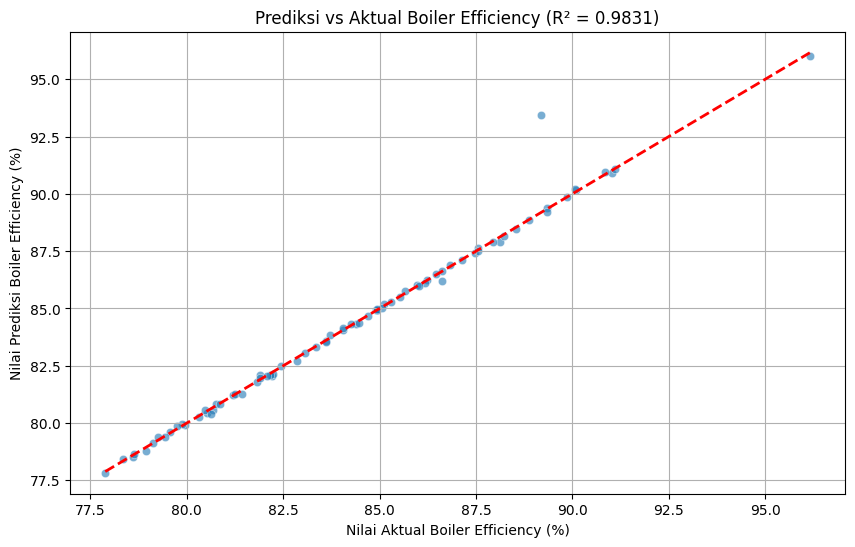

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 7. VISUALISASI HASIL PREDIKSI VS AKTUAL
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Nilai Aktual Boiler Efficiency (%)')
plt.ylabel('Nilai Prediksi Boiler Efficiency (%)')
plt.title(f'Prediksi vs Aktual Boiler Efficiency (R² = {r2:.4f})')
plt.grid(True)
plt.show()

In [12]:
import pandas as pd

# 7. TABEL PERBANDINGAN AKTUAL VS PREDIKSI
# Membuat DataFrame perbandingan
comparison_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Absolute Error': np.abs(y_test - y_pred),
    'Percentage Error (%)': np.abs((y_test - y_pred) / y_test) * 100
})

# Menampilkan 10 baris pertama untuk pengecekan
print("Comparison Table (First 10 rows):")
print(comparison_df.head(10))

# Opsional: Simpan ke CSV jika diperlukan untuk laporan SEO
# comparison_df.to_csv('model_predictions_comparison.csv', index=False)

Comparison Table (First 10 rows):
     Actual Value  Predicted Value  Absolute Error  Percentage Error (%)
6       78.594982        78.500488        0.094494              0.120230
503     91.038767        90.926223        0.112545              0.123623
105     87.150020        87.125254        0.024766              0.028417
501     89.341219        89.381329        0.040110              0.044895
458     84.052587        84.046223        0.006364              0.007572
224     83.068353        83.068294        0.000059              0.000071
239     86.224621        86.241491        0.016870              0.019565
442     81.831814        81.809475        0.022338              0.027298
351     84.938134        84.912116        0.026017              0.030631
73      82.202605        82.040274        0.162331              0.197477


In [13]:
# 8. EXPORT TO EXCEL
# Menentukan nama file
file_name = "f. #1 model prediction comparison dataset 3.xlsx"

# Menyimpan DataFrame ke file Excel
comparison_df.to_excel(file_name, index=False)

print(f"Data successfully saved to {file_name}!")

Data successfully saved to f. #1 model prediction comparison dataset 3.xlsx!
